# 🤖 Notebook 5 — Generation & Full RAG Pipeline (Phase 2)

هذا الـ notebook يُجرّب:
1. **توليد الإجابة** بـ Gemini مع سياق مسترجع
2. **Context prompt** — كيف يُبنى الـ prompt؟
3. **Quality validation** و **Fallback mechanism**
4. **Caching** — كيف يوفّر الـ API calls؟
5. **RAGPipeline** — الـ pipeline الكامل end-to-end
6. **Multi-turn conversation** تفاعلي
7. **Batch processing**

> ⚠️ يحتاج: Qdrant شغّال + collection مبنية + GEMINI_API_KEY
---

In [1]:
import sys, os, time
sys.path.append(os.path.abspath('..'))

from app.config import get_settings
from app.rag.embeddings import E5Embedder
from app.rag.vector_store import QdrantVectorStore
from app.rag.retriever import Retriever
from app.rag.generation import (
    GeminiGenerator, build_context_block, build_prompt, SYSTEM_INSTRUCTION
)
from app.rag.query_processing import ConversationContext
from app.rag.pipeline import RAGPipeline
from app.rag.cache import LRUCache
from app.rag.metrics import METRICS

settings  = get_settings()
embedder  = E5Embedder(settings)
store     = QdrantVectorStore(settings, dimension=embedder.dimension)
retriever = Retriever(embedder, store, settings)
generator = GeminiGenerator(settings)

print(f'Collection: {store.count()} points')
print(f'Generation model: {settings.gemini_generation_model}')
print(f'Temperature: {settings.generation_temperature}')
print(f'Max tokens: {settings.generation_max_tokens}')

c:\Users\EXPRESS\Anaconda3\envs\QA\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3173.39it/s]


Collection: 2040 points
Generation model: gemini-2.5-flash
Temperature: 0.2
Max tokens: 1024


c:\Users\EXPRESS\Anaconda3\envs\QA\Lib\site-packages\qdrant_client\qdrant_remote.py:282: UserWarning: Qdrant client version 1.18.0 is incompatible with server version 1.13.2. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  show_warning(


## 1. System Instruction — الـ prompt الثابت

In [2]:
print('System Instruction التي تُرسل مع كل طلب لـ Gemini:')
print('─' * 60)
print(SYSTEM_INSTRUCTION)
print('─' * 60)
print()
print('لماذا هذا التعليم مهم؟')
print('→ بدونه يُجيب Gemini من معرفته العامة (hallucination)')
print('→ بدونه لا يُشير للمقاطع [1], [2]')
print('→ بدونه قد يُجيب بلغة مختلفة عن لغة السؤال')

System Instruction التي تُرسل مع كل طلب لـ Gemini:
────────────────────────────────────────────────────────────
You are a precise, multilingual question-answering assistant for a knowledge platform. Answer ONLY from the provided context. If the context is insufficient, say you don't have enough information. Be concise and factual. Reply in the same language as the user's question.
────────────────────────────────────────────────────────────

لماذا هذا التعليم مهم؟
→ بدونه يُجيب Gemini من معرفته العامة (hallucination)
→ بدونه لا يُشير للمقاطع [1], [2]
→ بدونه قد يُجيب بلغة مختلفة عن لغة السؤال


## 2. بناء الـ Prompt — خطوة بخطوة

In [3]:
# الخطوة 1: استرجاع المقاطع
question = "Who had the most wins in the NFL?"
ranked   = retriever.retrieve(question, top_k=3)

print(f'السؤال: {question}')
print(f'عدد المقاطع المسترجعة: {len(ranked)}')
for i, r in enumerate(ranked, 1):
    print(f'  [{i}] score={r.final_score:.4f} | {r.payload.get("question","")[:60]}')

السؤال: Who had the most wins in the NFL?
عدد المقاطع المسترجعة: 3
  [1] score=0.8942 | who had the most wins in the nfl
  [2] score=0.8496 | who has won the most super bowl championships
  [3] score=0.8444 | who has won the most super bowl championships


In [4]:
# الخطوة 2: بناء context block
context_block = build_context_block(ranked)
print('Context Block الذي سيُرسل لـ Gemini:')
print('─' * 60)
print(context_block[:1500])
print('─' * 60)
print(f'الطول الكلي: {len(context_block)} chars')

Context Block الذي سيُرسل لـ Gemini:
────────────────────────────────────────────────────────────
[1] (domain=sports, score=0.89)
Active quarterback Tom Brady holds the records for most wins with 220, most regular season wins with 195, and most postseason wins with 25, as of Week 16 of the 2017 NFL season. Having played the entirety of his career with the New England Patriots, each of Brady's win records also apply to wins with a single team.

[2] (domain=sports, score=0.85)
The Pittsburgh Steelers (--) have won the most Super Bowls with six championships, while the New England Patriots (-), the Dallas Cowboys (--), and the San Francisco 49ers (--) have five wins. New England has the most Super Bowl appearances with nine, while the Buffalo Bills (--) have the most consecutive appearances with four losses in a row from 1990 to 1993. The Miami Dolphins are the only other team to have at least three consecutive appearances: 1972 -- 74. The Denver Broncos (--) have lost a record five Super

In [5]:
# الخطوة 3: بناء الـ prompt الكامل
full_prompt = build_prompt(question, context_block, context=None)
print('Full Prompt (بدون سياق محادثة):')
print('─' * 60)
print(full_prompt[:2000])
print('─' * 60)
print(f'طول الـ prompt: {len(full_prompt)} chars')

Full Prompt (بدون سياق محادثة):
────────────────────────────────────────────────────────────
Context passages:
[1] (domain=sports, score=0.89)
Active quarterback Tom Brady holds the records for most wins with 220, most regular season wins with 195, and most postseason wins with 25, as of Week 16 of the 2017 NFL season. Having played the entirety of his career with the New England Patriots, each of Brady's win records also apply to wins with a single team.

[2] (domain=sports, score=0.85)
The Pittsburgh Steelers (--) have won the most Super Bowls with six championships, while the New England Patriots (-), the Dallas Cowboys (--), and the San Francisco 49ers (--) have five wins. New England has the most Super Bowl appearances with nine, while the Buffalo Bills (--) have the most consecutive appearances with four losses in a row from 1990 to 1993. The Miami Dolphins are the only other team to have at least three consecutive appearances: 1972 -- 74. The Denver Broncos (--) have lost a reco

## 3. توليد الإجابة بـ Gemini

In [6]:
from app.rag.retriever import Retriever as R

confidence = R.confidence(ranked)
print(f'Confidence: {confidence:.4f}')
print(f'Will generate (above threshold): {confidence >= settings.min_confidence}')
print()

t0 = time.perf_counter()
result = generator.generate(question, ranked, confidence)
elapsed = (time.perf_counter() - t0) * 1000

print('═' * 60)
print(f'Question      : {question}')
print(f'Answer        : {result.answer}')
print(f'Used fallback : {result.used_fallback}')
print(f'Quality passed: {result.quality_passed}')
print(f'Quality notes : {result.quality_notes}')
print(f'Finish reason : {result.finish_reason}')
print(f'Latency       : {elapsed:.0f}ms')
print('═' * 60)

Confidence: 0.9591
Will generate (above threshold): True

════════════════════════════════════════════════════════════
Question      : Who had the most wins in the NFL?
Answer        : Active quarterback Tom Brady holds the record for most wins in the NFL with 220, as of Week 16 of the 2017 NFL season [1].
Used fallback : False
Quality passed: True
Quality notes : []
Finish reason : FinishReason.STOP
Latency       : 3156ms
════════════════════════════════════════════════════════════


## 4. Fallback Mechanism — اختبار الـ fallback

In [7]:
from app.rag.retriever import RankedHit
from app.rag.vector_store import SearchHit

print('اختبار 1: confidence أقل من threshold (0.30)')
fake_hit = SearchHit(id='test', score=0.1, payload={'text': 'unrelated text'})
fake_ranked = [RankedHit(fake_hit, 0.1, 0.0, 0.1)]
res_low = generator.generate("What is the capital of Mars?", fake_ranked, confidence=0.15)
print(f'  used_fallback: {res_low.used_fallback}')
print(f'  answer: {res_low.answer[:100]}')

print()
print('اختبار 2: قائمة فارغة من النتائج')
res_empty = generator.generate("random question", [], confidence=0.0)
print(f'  used_fallback: {res_empty.used_fallback}')
print(f'  answer: {res_empty.answer[:100]}')

اختبار 1: confidence أقل من threshold (0.30)
  used_fallback: True
  answer: I don't have enough reliable information in my knowledge base to answer that confidently. Could you 

اختبار 2: قائمة فارغة من النتائج
  used_fallback: True
  answer: I don't have enough reliable information in my knowledge base to answer that confidently. Could you 


## 5. LRU Cache — الاستفادة من التخزين المؤقت

In [8]:
cache = LRUCache(capacity=5, ttl_seconds=60)

# ملء الـ cache
cache.set('q1', 'answer for q1')
cache.set('q2', 'answer for q2')
cache.set('q3', 'answer for q3')

# hit
print(f'get q1: {cache.get("q1")} (hit)')
print(f'get q1: {cache.get("q1")} (hit again)')

# miss
print(f'get q99: {cache.get("q99")} (miss)')

# إحصائيات
print(f'\nCache stats: {cache.stats()}')

# اختبار LRU eviction
for i in range(4, 8):
    cache.set(f'q{i}', f'answer {i}')

print(f'\nبعد إضافة 4 مزيد (capacity=5):')
print(f'q2 لا يزال موجوداً: {cache.get("q2") is not None}')  # قد يكون أُزيل
print(f'Cache stats: {cache.stats()}')

get q1: answer for q1 (hit)
get q1: answer for q1 (hit again)
get q99: None (miss)

Cache stats: {'size': 3, 'capacity': 5, 'hits': 2, 'misses': 1, 'hit_rate': 0.667}

بعد إضافة 4 مزيد (capacity=5):
q2 لا يزال موجوداً: False
Cache stats: {'size': 5, 'capacity': 5, 'hits': 2, 'misses': 2, 'hit_rate': 0.5}


## 6. RAGPipeline الكامل — End-to-End

In [9]:
pipeline = RAGPipeline(settings)

# سؤال واحد
t0 = time.perf_counter()
resp = pipeline.answer("Who had the most wins in the NFL?")
elapsed = (time.perf_counter() - t0) * 1000

print('╔══════════════════════════════════════════════════════╗')
print(f'║ Question  : {resp.question[:48]}')
print(f'║ Answer    : {resp.answer[:48]}')
print(f'║ Confidence: {resp.confidence:.4f}')
print(f'║ Fallback  : {resp.used_fallback}')
print(f'║ Cached    : {resp.cached}')
print(f'║ Latency   : {elapsed:.0f}ms')
print(f'║ Passages  : {len(resp.passages)}')
print('╚══════════════════════════════════════════════════════╝')
print()
print('Full Answer:')
print(resp.answer)

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 3347.48it/s]
c:\Users\EXPRESS\Anaconda3\envs\QA\Lib\site-packages\qdrant_client\qdrant_remote.py:282: UserWarning: Qdrant client version 1.18.0 is incompatible with server version 1.13.2. Major versions should match and minor version difference must not exceed 1. Set check_compatibility=False to skip version check.
  show_warning(


╔══════════════════════════════════════════════════════╗
║ Question  : Who had the most wins in the NFL?
║ Answer    : Active quarterback Tom Brady holds the records f
║ Confidence: 0.9591
║ Fallback  : False
║ Cached    : False
║ Latency   : 17161ms
║ Passages  : 5
╚══════════════════════════════════════════════════════╝

Full Answer:
Active quarterback Tom Brady holds the records for most wins with 220, most regular season wins with 195, and most postseason wins with 25, as of Week 16 of the 2017 NFL season [1].


In [10]:
# الـ cache في العمل — نفس السؤال مرة ثانية
t0 = time.perf_counter()
resp2 = pipeline.answer("Who had the most wins in the NFL?")
elapsed2 = (time.perf_counter() - t0) * 1000

print(f'المرة الأولى  : ~{elapsed:.0f}ms  (cached={resp.cached})')
print(f'المرة الثانية : ~{elapsed2:.0f}ms  (cached={resp2.cached})')
print(f'Speed-up: {elapsed/max(elapsed2,1):.1f}x أسرع من الـ cache')

المرة الأولى  : ~17161ms  (cached=False)
المرة الثانية : ~1ms  (cached=True)
Speed-up: 16200.0x أسرع من الـ cache


## 7. Multi-turn Conversation — محادثة حقيقية

In [11]:
import uuid
conv_id = uuid.uuid4().hex
print(f'Conversation ID: {conv_id}\n')

conversation = [
    "Who had the most wins in the NFL?",
    "Which team is he famous for?",      # follow-up — يحتاج سياق
    "How many Super Bowls did he win?",  # follow-up آخر
]

for i, q in enumerate(conversation, 1):
    print(f'{'─'*60}')
    resp = pipeline.answer(q, conversation_id=conv_id)
    print(f'[{i}] User: {q}')
    print(f'[{i}] Bot : {resp.answer[:200]}')
    print(f'      confidence={resp.confidence:.3f} | passages={len(resp.passages)}')
    print()

Conversation ID: 88aa7b006daa4e9a9961084fefc18050

────────────────────────────────────────────────────────────
[1] User: Who had the most wins in the NFL?
[1] Bot : Active quarterback Tom Brady holds the records for most wins with 220, most regular season wins with 195, and most postseason wins with 25, as of Week 16 of the 2017 NFL season [1].
      confidence=0.959 | passages=5

────────────────────────────────────────────────────────────
[2] User: Which team is he famous for?
[2] Bot : He played the entirety of his career with the New England Patriots [1].
      confidence=0.934 | passages=5

────────────────────────────────────────────────────────────
[3] User: How many Super Bowls did he win?
[3] Bot : I don't have enough information about how many Super Bowls Tom Brady won. The context mentions the New England Patriots won Super Bowls in 2001, 2003, and 2004, and won three out of four consecutive S
      confidence=0.896 | passages=5



In [12]:
# عرض تاريخ المحادثة المحفوظ في الـ pipeline
ctx = pipeline._conversations.get(conv_id)
if ctx:
    print(f'المحادثة المحفوظة ({len(ctx.history)} أدوار):')
    print(ctx.as_text())
else:
    print('لم يُحفظ تاريخ')

المحادثة المحفوظة (3 أدوار):
User: Who had the most wins in the NFL?
Assistant: Active quarterback Tom Brady holds the records for most wins with 220, most regular season wins with 195, and most postseason wins with 25, as of Week 16 of the 2017 NFL season [1].
User: Which team is he famous for?
Assistant: He played the entirety of his career with the New England Patriots [1].
User: How many Super Bowls did he win?
Assistant: I don't have enough information about how many Super Bowls Tom Brady won. The context mentions the New England Patriots won Super Bowls in 2001, 2003, and 2004, and won three out of four consecutive Super Bowls (2001; 2003 -- 04) [1].


## 8. Batch Processing

In [13]:
batch_questions = [
    "Who had the most wins in the NFL?",
    "What is opt-in email marketing?",
    "Who is the mother in How I Met Your Mother?",
]

t0 = time.perf_counter()
batch_results = pipeline.batch_answer(batch_questions)
elapsed = time.perf_counter() - t0

print(f'Processed {len(batch_results)} questions in {elapsed:.1f}s')
print(f'Average : {elapsed/len(batch_results):.1f}s per question\n')

for q, r in zip(batch_questions, batch_results):
    print(f'Q: {q}')
    print(f'A: {r.answer[:150]}')
    print(f'   conf={r.confidence:.3f} | cached={r.cached}')
    print()

Processed 3 questions in 5.2s
Average : 1.7s per question

Q: Who had the most wins in the NFL?
A: Active quarterback Tom Brady holds the records for most wins with 220, most regular season wins with 195, and most postseason wins with 25, as of Week
   conf=0.959 | cached=True

Q: What is opt-in email marketing?
A: Opt-in email marketing is a form of permission marketing where a company asks customers if they would like to receive a newsletter, often at the point
   conf=0.937 | cached=False

Q: Who is the mother in How I Met Your Mother?
A: The mother in How I Met Your Mother is Tracy McConnell, played by Cristina Militia [1, 2, 3].
   conf=0.963 | cached=False



## 9. Performance Metrics Snapshot

In [14]:
import json
snapshot = METRICS.snapshot()
print('Performance Metrics:')
print(json.dumps(snapshot, indent=2))
print()
print('Health check:')
health = pipeline.health()
print(json.dumps({k: str(v)[:80] for k, v in health.items()}, indent=2))

Performance Metrics:
{
  "uptime_seconds": 357.8,
  "operations": {
    "embedding": {
      "count": 7,
      "avg_ms": 3411.2,
      "p50_ms": 739.33,
      "p95_ms": 13391.16,
      "throughput_per_min": 1.17
    },
    "search": {
      "count": 7,
      "avg_ms": 152.09,
      "p50_ms": 134.5,
      "p95_ms": 365.28,
      "throughput_per_min": 1.17
    },
    "generation": {
      "count": 6,
      "avg_ms": 2675.19,
      "p50_ms": 2700.13,
      "p95_ms": 3513.03,
      "throughput_per_min": 1.01
    },
    "end_to_end": {
      "count": 6,
      "avg_ms": 5481.73,
      "p50_ms": 2965.8,
      "p95_ms": 17143.58,
      "throughput_per_min": 1.01
    }
  }
}

Health check:
{
  "gemini_model": "gemini-2.5-flash",
  "embedding_model": "intfloat/multilingual-e5-large",
  "vector_store": "{'collection': 'natural_questions', 'exists': True, 'points': 2040, 'dimension':",
  "cache": "{'size': 3, 'capacity': 512, 'hits': 2, 'misses': 3, 'hit_rate': 0.4}",
  "metrics": "{'uptime_second

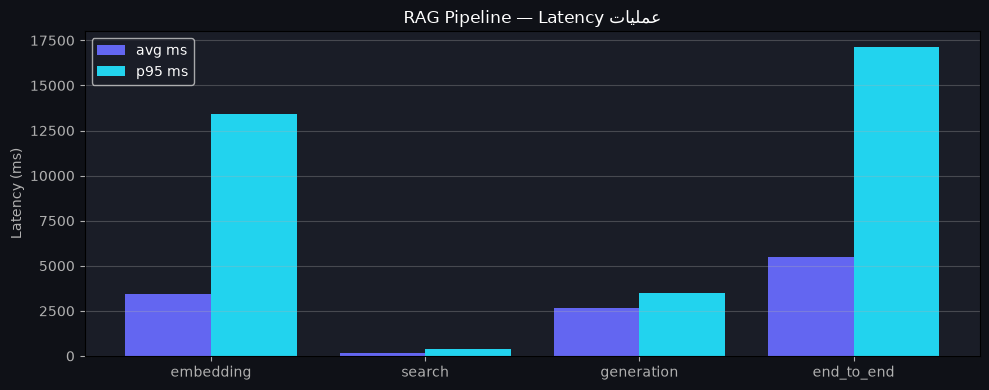

In [15]:
# رسم latency لكل عملية
import matplotlib.pyplot as plt
ops = snapshot.get('operations', {})
if ops:
    op_names   = list(ops.keys())
    avg_ms     = [ops[o]['avg_ms']  for o in op_names]
    p95_ms     = [ops[o]['p95_ms']  for o in op_names]

    x = range(len(op_names))
    fig, ax = plt.subplots(figsize=(10, 4), facecolor='#0f1117')
    ax.set_facecolor('#1a1d27')
    ax.bar([i - 0.2 for i in x], avg_ms, 0.4, label='avg ms', color='#6366f1')
    ax.bar([i + 0.2 for i in x], p95_ms, 0.4, label='p95 ms', color='#22d3ee')
    ax.set_xticks(list(x)); ax.set_xticklabels(op_names, color='#b0b0b0')
    ax.set_ylabel('Latency (ms)', color='#b0b0b0')
    ax.set_title('عمليات RAG Pipeline — Latency', color='white')
    ax.legend(facecolor='#1a1d27', labelcolor='white')
    ax.tick_params(colors='#b0b0b0')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('No metrics yet — run some queries first')